# A small Norwegian earthquake

This notebook looks at seismic data from a small earthquake in Norway on 2 July 2026.

We can also see the major, devastating, event in Venezuela — from Norway.


## Get the data

In [1]:
from obspy.clients.fdsn import Client

client = Client("EIDA")

inventory = client.get_stations(
    network="NS", 
    station="BER", 
    level="channel"
)

inventory

Inventory created at 2026-07-03T14:55:25.222395Z
	Sending institution: EIDA-Federator (EIDA)
	Contains:
		Networks (1):
			NS
		Stations (1):
			NS.BER (Bergen, Norway)
		Channels (3):
			NS.BER.00.HHZ, NS.BER.00.HHN (2x)

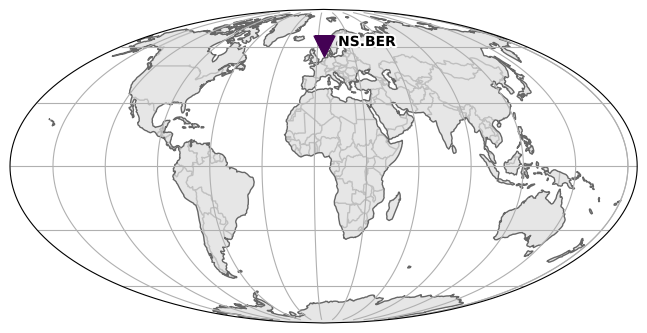

In [2]:
_ = inventory.plot(projection='global', color=0.15)

## Get the data

I'm just following the [instructions in the ObsPy documentation](https://docs.obspy.org/packages/obspy.clients.fdsn.html).

The event was at about 18:12 am local, which is two hours ahead of UTC.

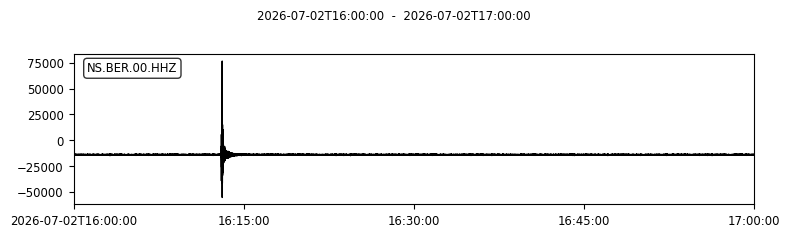

In [3]:
from obspy import UTCDateTime

t0 = UTCDateTime("2026-07-02T16:00:00")
t1 = t0 + 3600

# 'HHZ' is the High-Broadband, High-Gain Vertical channel; 'HHN' is the same, but North-South not Vertical.
st = client.get_waveforms(network="NS", station="BER", location="00", channel="HHZ", starttime=t0, endtime=t1)

_ = st.plot()

## Listen to the bang

We can listen to it! We'll use IPython to 'display' the array as audio, multiplying the sample interval by 60 to speed it up by that factor — so one minute of data lasts one second on this recording. That way, your computer might be able to reproduce it, and we might be able to hear it.

The earthquake happens at about 13 seconds.

In [4]:
sig = st.traces[0].data
Fs = st.traces[0].meta.sampling_rate

In [5]:
import IPython.display as ipd

ipd.Audio(sig, rate=Fs*60)

We can also write a file.

In [6]:
import numpy as np
from scipy.io import wavfile

N = int(Fs*60) # Samples per second
wavfile.write('earthquake.wav', N, sig.astype(np.int16))

## Spectrogram

It's common to look at the data spread out in frequency in a so-called 'spectrogram'. 

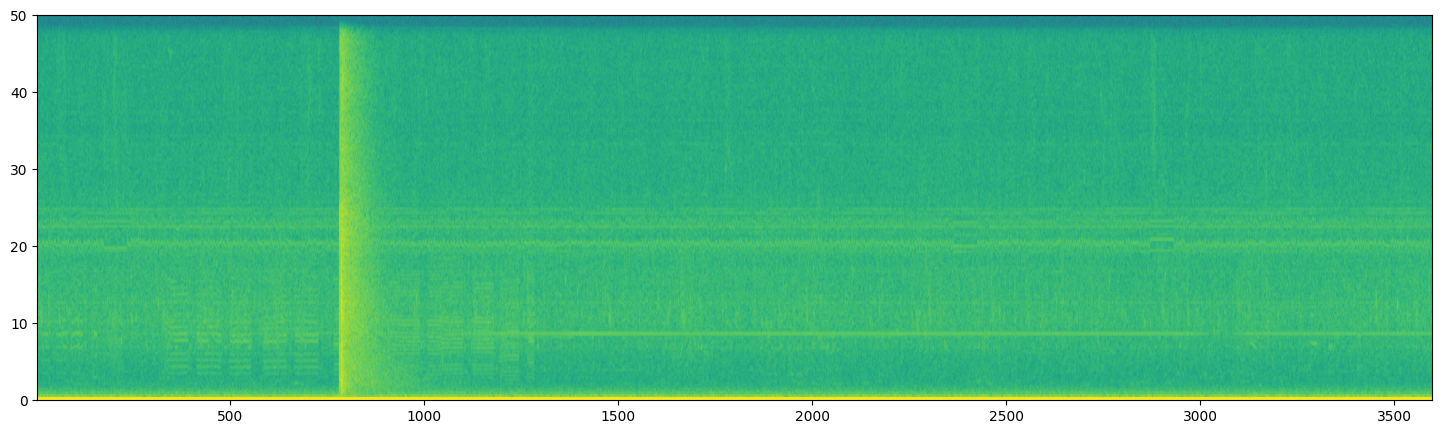

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))
NFFT = 512
_ = plt.specgram(sig, Fs=Fs, NFFT=NFFT, noverlap=int(0.9*NFFT))

We can make a slightly nicer plot:

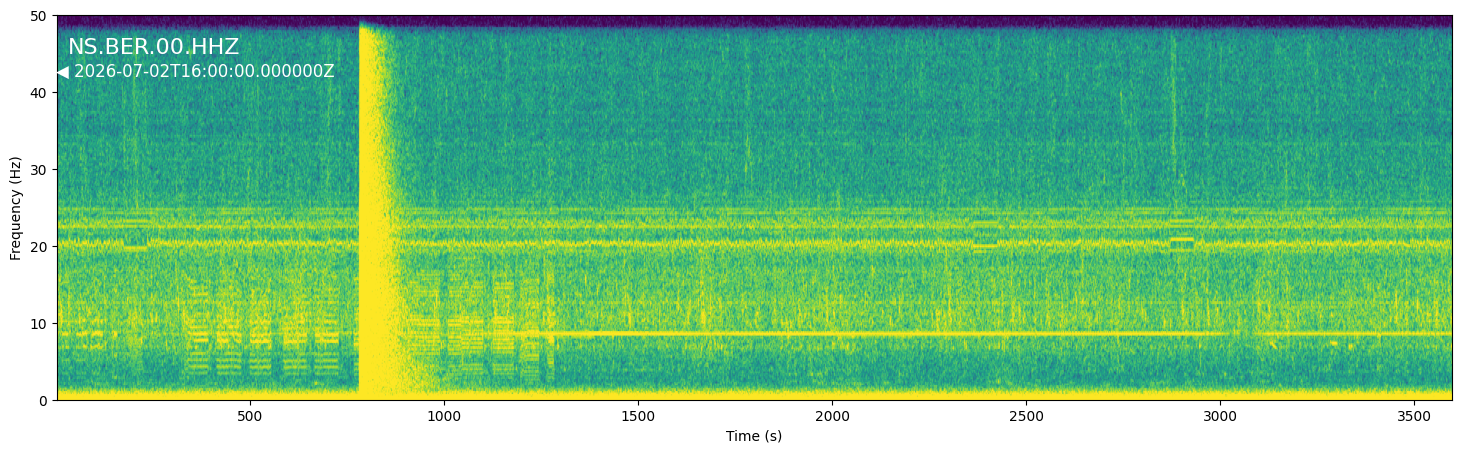

In [8]:
label = "{network}.{station}.{location}.{channel}".format(**st.traces[0].meta)

plt.figure(figsize=(18, 5))
Pxx, freqs, bins, im = plt.specgram(sig, Fs=Fs,
                                    NFFT=NFFT, noverlap=int(0.9*NFFT),
                                    vmin=-30, vmax=30,)
plt.text(30, 45, label, size=16, color='white')
plt.text(0, 42, "◀ " + str(t0), size=12, color='white')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()

There's clearly quite a bit of noise in there too.

## The Venezuela event

Although it was about 8000 km away, the Bergen seismic station could easily record [the devastating Venezuela earthquake](https://en.wikipedia.org/wiki/2026_Venezuela_earthquakes) on 24 June.

We clearly see both the primary P-wave arrivals, and the slower S-wave arrivals half an hour later.

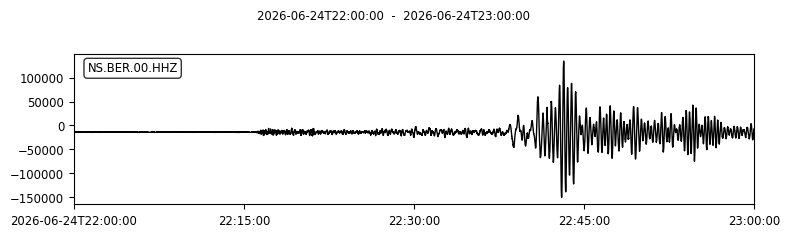

In [9]:
t0 = UTCDateTime("2026-06-24T22:00:00")
t1 = t0 + 3600

# 'HHZ' is the High-Broadband, High-Gain Vertical channel; 'HHN' is the same, but North-South not Vertical.
st = client.get_waveforms(network="NS", station="BER", location="00", channel="HHZ", starttime=t0, endtime=t1)

_ = st.plot()

Listen very closely at about 41 seconds:

In [10]:
sig = st.traces[0].data
Fs = st.traces[0].meta.sampling_rate

ipd.Audio(sig, rate=Fs*60)

Again, a lot of noise, but we see how attentuated the high frequencies are after the earthquake has traveled across the earth.

The event was at 22:04 UTC, so we see that it takes the P-waves about 12 minutes to arrive, and the S-waves about 35 minutes.

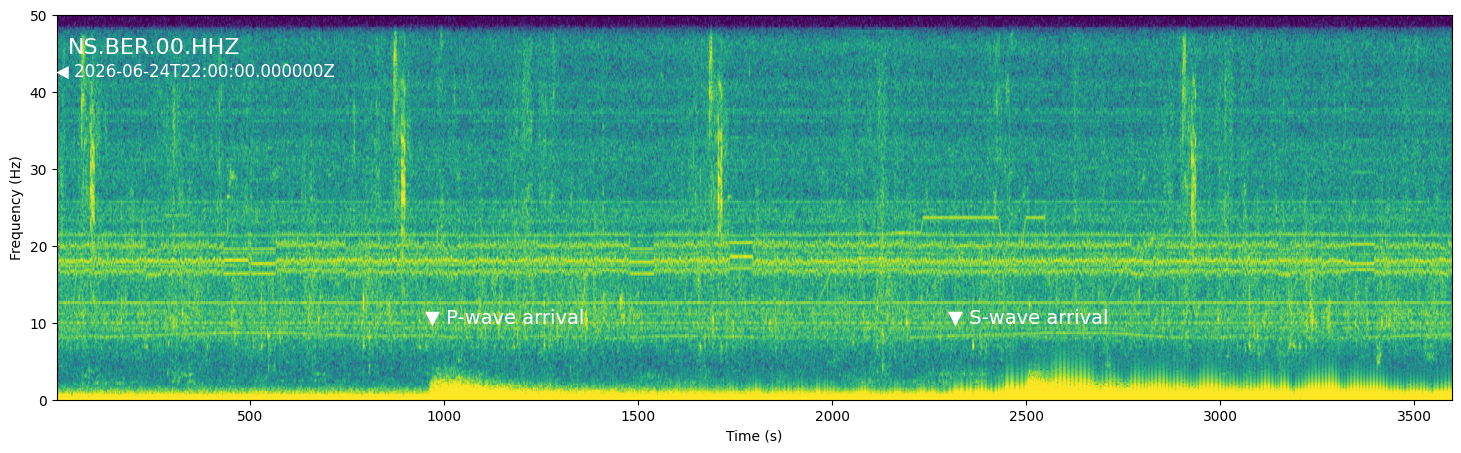

In [11]:
label = "{network}.{station}.{location}.{channel}".format(**st.traces[0].meta)

plt.figure(figsize=(18, 5))
Pxx, freqs, bins, im = plt.specgram(sig, Fs=Fs,
                                    NFFT=NFFT, noverlap=int(0.9*NFFT),
                                    vmin=-30, vmax=30,)
plt.text(30, 45, label, size=16, color='white')
plt.text(0, 42, "◀ " + str(t0), size=12, color='white')
plt.text(950, 10, "▼ P-wave arrival", size=14, color='white')
plt.text(2300, 10, "▼ S-wave arrival", size=14, color='white')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()

<hr />

© 2026 Matt Hall, licensed CC BY-SA